In [7]:
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [8]:
ROOT = Path.cwd()

EXP = ROOT / "results" / "experiments"

AT_ADM = EXP / "icd_codes"

UPTO_ADM = EXP / "icd_codes_upto"

In [9]:
all_dfs = []

# Iterate over subfolders
for folder in EXP.iterdir():
    for subfolder in folder.iterdir():
        if subfolder.is_dir():
            csv_file = subfolder / "summary_metrics.csv"
            
            if csv_file.exists():
                df = pd.read_csv(csv_file)
                
                # Add folder name as new column
                df["folder_name"] = subfolder.name
                df["adm_type"] = folder.name
                
                all_dfs.append(df)

# Concatenate all dataframes
if all_dfs:
    concat_df = pd.concat(all_dfs, ignore_index=True)
else:
    concat_df = pd.DataFrame()

In [10]:
concat_df["cohort_name"] = np.where(concat_df["folder_name"].str.contains("aplasia", case=False, na=False), "aplasia", "neutropenic fever")

concat_df.loc[concat_df["Feature_Type"].isna() & concat_df["folder_name"].str.contains("node2vec"),"Feature_Type"] = "Node2Vec"
concat_df.loc[concat_df["Feature_Type"].isna() & concat_df["folder_name"].str.contains("kane"),"Feature_Type"] = "Kane"

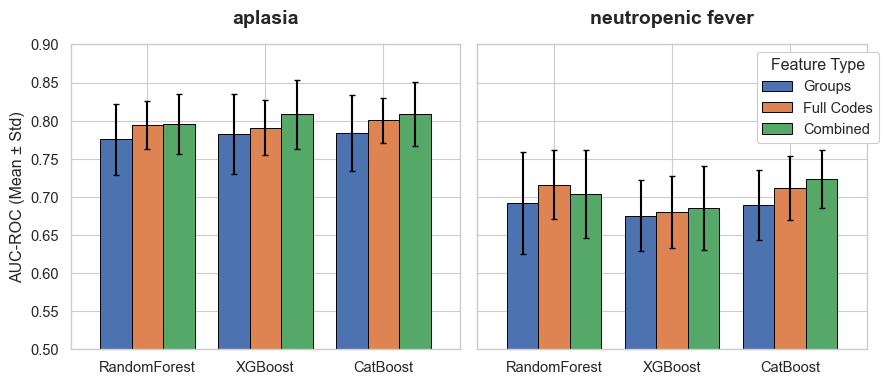

In [ ]:
# FIGURE 1 - FULL CODES vs GROUPS vs COMBINED

# NOTE THE Y LIM [0.5, 0.9]

sub_df = concat_df[concat_df["folder_name"].str.contains("OHE") & (concat_df["adm_type"]=="icd_codes")]

feature_order = ["Groups", "Full Codes", "Combined"]
model_order = ['RandomForest', 'XGBoost', 'CatBoost']
cohort_order = sub_df["cohort_name"].unique()

sns.set(style="whitegrid", context="paper", font_scale=1.2)

fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharey=True)

for i, (ax, cohort) in enumerate(zip(axes, cohort_order)):
    
    cohort_df = sub_df[sub_df["cohort_name"] == cohort]
    
    # Pivot Data
    p_mean = cohort_df.pivot(index="Model", columns="Feature_Type", values="Test_AUC_Mean")
    p_std = cohort_df.pivot(index="Model", columns="Feature_Type", values="Test_AUC_Std")
    
    # Reindex
    p_mean = p_mean.reindex(index=model_order, columns=feature_order)
    p_std = p_std.reindex(index=model_order, columns=feature_order)

    # PLOT
    p_mean.plot(
        kind="bar",
        yerr=p_std,
        ax=ax,
        capsize=2,
        width=0.8,
        edgecolor="black",
        linewidth=0.7,
        rot=0,
        error_kw={"elinewidth": 1.5, "ecolor": "black"}
    )
    
    #ax.set_title(cohort)
    ax.set_title(cohort, fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel("")
    ax.set_ylabel("AUC-ROC (Mean ± Std)" if i==0 else "") 
    ax.set_ylim(0.5, 0.9)

    # Clean Legend
    if i == 0:
        ax.get_legend().remove()
    else:
        ax.legend(title="Feature Type", frameon=True, fancybox=True, framealpha=1, bbox_to_anchor=(1.05, 1))

os.makedirs("figures", exist_ok=True)
plt.tight_layout()
plt.savefig("figures/fig1.png", dpi=400)

In [21]:
# FIGURE 2 

sub_df = concat_df[(concat_df["adm_type"]=="icd_codes") & concat_df["Feature_Type"].isin(['Kane', 'Word2Vec', 'Node2Vec'])].copy()

model_order = ["RandomForest", "XGBoost", "CatBoost", "MLP_1Layer", "MLP_2Layer", "MLP_3Layer"]

sub_df["Model"] = pd.Categorical(sub_df["Model"], categories=model_order, ordered=True)

sub_df = sub_df.sort_values(["Model", "Dimension"])

In [22]:
sub_df.groupby(["Dimension", "Model"])["Test_AUC_Mean"].mean()#.sort_values()

C:\Users\Tanveer\AppData\Local\Temp\ipykernel_32036\516749367.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sub_df.groupby(["Dimension", "Model"])["Test_AUC_Mean"].mean()#.sort_values()


Dimension  Model       
10.0       RandomForest    0.607949
           XGBoost         0.597286
           CatBoost        0.614525
           MLP_1Layer      0.646555
           MLP_2Layer      0.636922
           MLP_3Layer      0.634835
50.0       RandomForest    0.645083
           XGBoost         0.637895
           CatBoost        0.650841
           MLP_1Layer      0.699798
           MLP_2Layer      0.699091
           MLP_3Layer      0.700979
100.0      RandomForest    0.657982
           XGBoost         0.657096
           CatBoost        0.661149
           MLP_1Layer      0.694085
           MLP_2Layer      0.699793
           MLP_3Layer      0.700594
1000.0     RandomForest    0.664782
           XGBoost         0.666752
           CatBoost        0.664641
           MLP_1Layer      0.703808
           MLP_2Layer      0.698730
           MLP_3Layer      0.701281
Name: Test_AUC_Mean, dtype: float64

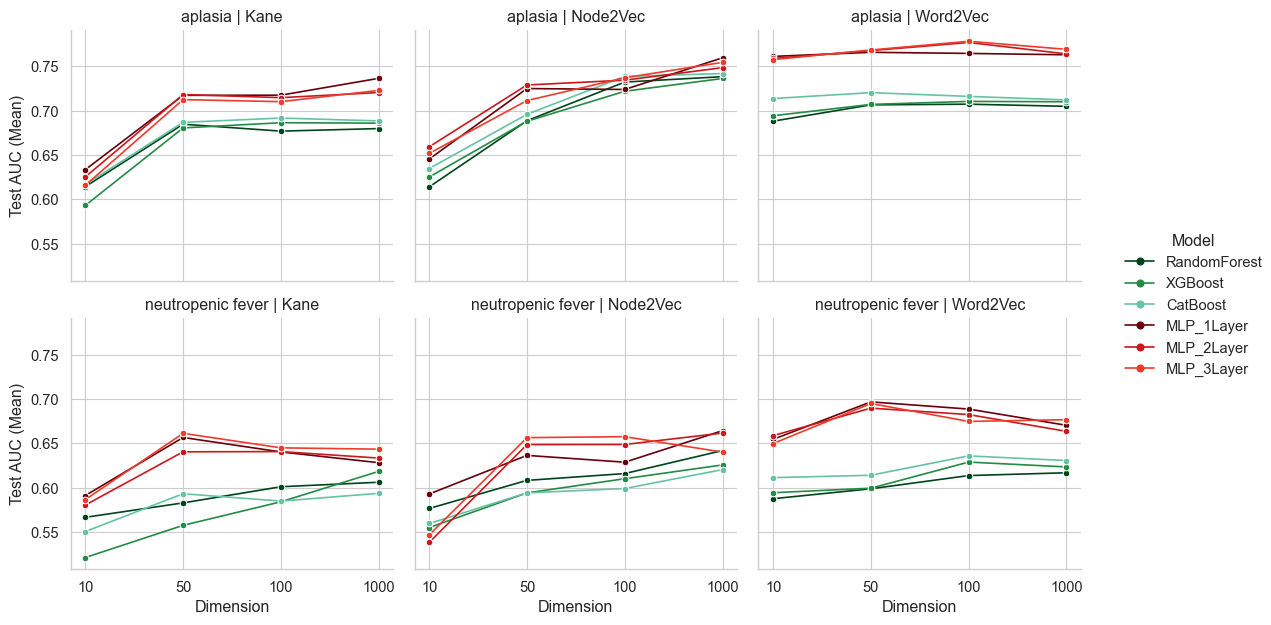

In [23]:
sub_df["Dimension_str"] = sub_df["Dimension"].astype(int).astype(str)

# Define a palette with shades
palette = {
    # Tree-based (greens)
    "RandomForest": "#00441B",  # very dark green
    "XGBoost": "#238B45",       # medium green
    "CatBoost": "#66C2A4",      # light green

    # MLP (reds)
    "MLP_1Layer": "#67000D",    # very dark red
    "MLP_2Layer": "#CB181D",    # medium red
    "MLP_3Layer": "#EF3B2C"     # light red
}


g = sns.relplot(
    data=sub_df,
    kind="line",
    x="Dimension_str",
    y="Test_AUC_Mean",
    hue="Model",
    #style="Model",
    col="Feature_Type",
    row="cohort_name",
    marker="o",
    palette=palette,
    height=3.2,
    aspect=1
)

g.set_axis_labels("Dimension", "Test AUC (Mean)")
g.set_titles(row_template="{row_name}", col_template="{col_name}")
g._legend.set_bbox_to_anchor((1.15, 0.5)) 
plt.tight_layout()
plt.savefig("figures/fig2.png", dpi=400)


In [24]:
# FIGURE 3 upto vs at adm

# selected dimensionality (similar to ClinVec) = 100

# selected number of layers (best overall performance) = 3


In [25]:
sub_df = concat_df[
    (concat_df["Model"].isin(['RandomForest', 'XGBoost', 'CatBoost', 'MLP_3Layer'])) &
    (
        ((concat_df["Feature_Type"].isin(["Kane", "Word2Vec", "Node2Vec"])) & (concat_df["Dimension"] == 100)) |    # embeddings
        ((concat_df["folder_name"].str.contains("OHE")) & (concat_df["Feature_Type"] == "Combined"))                # one-hot
    )
].sort_values(["cohort_name", "Feature_Type", "Model"])
sub_df["Feature_Type"] = sub_df["Feature_Type"].replace({"Combined":"One-Hot"})
sub_df["Model"] = sub_df["Model"].replace({"MLP_3Layer":"MLP"})


In [26]:
pivot_df = sub_df.pivot_table(
    index=["Model", "Feature_Type", "cohort_name"], 
    columns="adm_type",  
    values="Test_AUC_Mean"
).reset_index()

pivot_df["diff_upto_at"] = pivot_df["icd_codes_upto"] - pivot_df["icd_codes"]

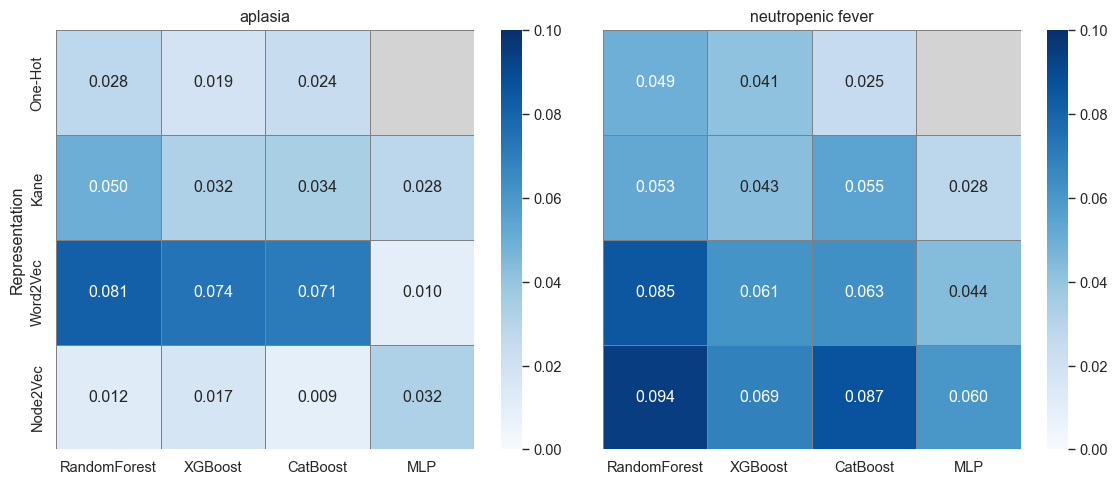

In [27]:
x_order = ['RandomForest', 'XGBoost', 'CatBoost', 'MLP']
y_order = ['One-Hot','Kane','Word2Vec','Node2Vec']

# Diverging palette: blue = positive
cmap = sns.color_palette("Blues", as_cmap=True)  # white → blue
cmap.set_bad(color='lightgray') 
# List of cohorts
cohorts = pivot_df["cohort_name"].unique()

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(11.5, 5), sharey=True)

for i, cohort in enumerate(cohorts):
    # Filter cohort
    df_cohort = pivot_df[pivot_df["cohort_name"] == cohort]
    
    # Pivot for heatmap
    heat_data = df_cohort.pivot(index="Feature_Type", columns="Model", values="diff_upto_at")
    
    # Reindex rows and columns to fix order
    heat_data = heat_data.reindex(index=y_order, columns=x_order)
    
    sns.heatmap(
        heat_data, 
        annot=True, fmt=".3f", 
        cmap=cmap,
        linewidths=0.5, linecolor="gray",
        vmin=0, vmax=0.1,  # set colorbar range
        ax=axes[i]
    )
    axes[i].set_title(f"{cohort}")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    axes[i].set_ylabel("Representation" if i == 0 else "")  # only left plot y-axis
    axes[i].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig("figures/fig3.png", dpi=400)

In [28]:
# FIGURE 4

all_dfs = []

# Iterate over subfolders
for folder in EXP.iterdir():
    for subfolder in folder.iterdir():
        if subfolder.is_dir():
            csv_file = subfolder / "metrics.csv"
            
            if csv_file.exists():
                df = pd.read_csv(csv_file)
                
                # Add folder name as new column
                df["folder_name"] = subfolder.name
                df["adm_type"] = folder.name
                
                all_dfs.append(df)

# Concatenate all dataframes
if all_dfs:
    metrics_df = pd.concat(all_dfs, ignore_index=True)
else:
    metrics_df = pd.DataFrame()

metrics_df["cohort_name"] = np.where(metrics_df["folder_name"].str.contains("aplasia", case=False, na=False), "aplasia", "neutropenic fever")

metrics_df.loc[metrics_df["Feature_Type"].isna() & metrics_df["folder_name"].str.contains("node2vec"),"Feature_Type"] = "Node2Vec"
metrics_df.loc[metrics_df["Feature_Type"].isna() & metrics_df["folder_name"].str.contains("kane"),"Feature_Type"] = "Kane"

In [29]:
sub_df = metrics_df[
    (metrics_df["Model"].isin(['RandomForest', 'XGBoost', 'CatBoost', 'MLP_3Layer'])) &
    (
        ((metrics_df["Feature_Type"].isin(["Kane", "Word2Vec", "Node2Vec"])) & (metrics_df["Dimension"] == 100)) |    # embeddings
        ((metrics_df["folder_name"].str.contains("OHE")) & (metrics_df["Feature_Type"] == "Combined"))                # one-hot
    )
].sort_values(["cohort_name", "Feature_Type", "Model"])
sub_df["Feature_Type"] = sub_df["Feature_Type"].replace({"Combined":"One-Hot"})
sub_df["Model"] = sub_df["Model"].replace({"MLP_3Layer":"MLP"})

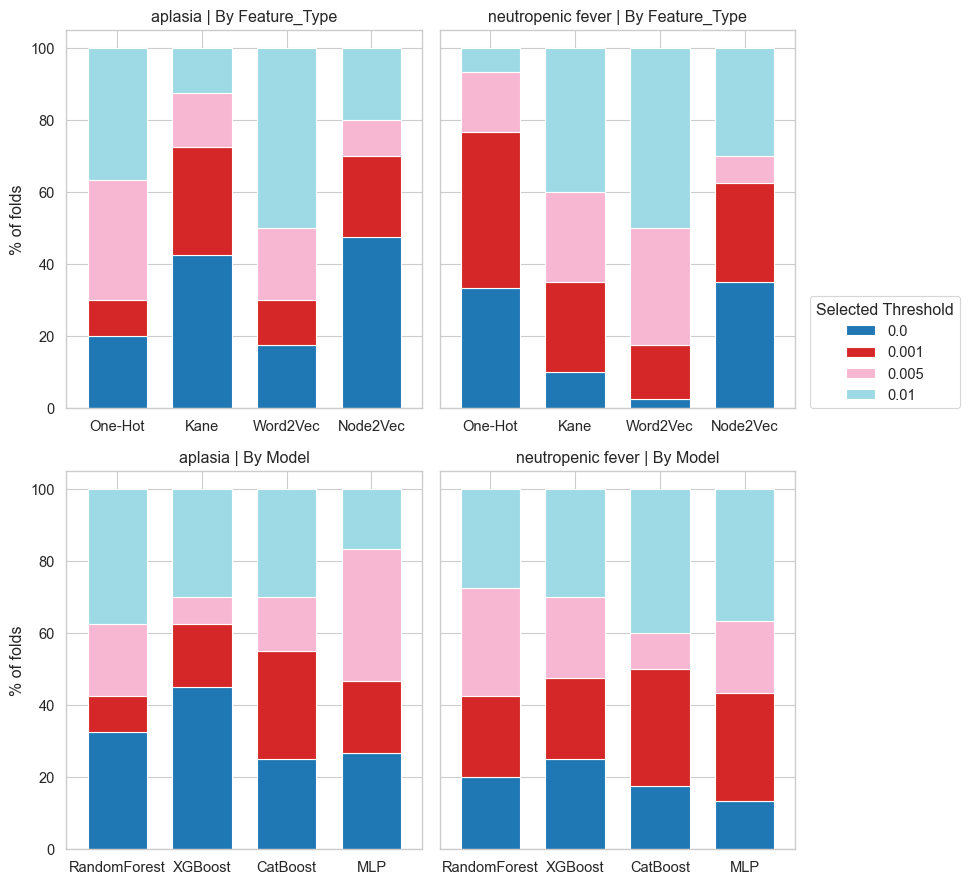

In [30]:
order1 = ['One-Hot','Kane','Word2Vec','Node2Vec']
order2 = ['RandomForest', 'XGBoost', 'CatBoost', 'MLP']

# Copy your dataframe
df = sub_df.copy()  # replace with your actual dataframe

# Unique cohorts
cohorts = df['Cohort'].unique()

# Set up 2x2 subplots
fig, axes = plt.subplots(2, len(cohorts), figsize=(5*len(cohorts), 9), sharey=True)

# Ensure axes is always 2D array
if len(cohorts) == 1:
    axes = axes.reshape(2,1)

for j, cohort in enumerate(["aplasia","neutropenic fever"]):
    df_cohort = df[df['cohort_name'] == cohort]

    # ------------------
    # Row 1: grouped by Feature_Type
    # ------------------
    counts = (
        df_cohort.groupby(['Feature_Type', 'Selected_Threshold'])
        .size()
        .reset_index(name='count')
    )
    counts['pct'] = counts.groupby('Feature_Type')['count'].transform(lambda x: x / x.sum() * 100)
    pivot = counts.pivot(index='Feature_Type', columns='Selected_Threshold', values='pct').fillna(0)
    pivot = pivot.reindex(index=order1)
    pivot.plot(
        kind='bar',
        stacked=True,
        ax=axes[0,j],
        colormap='tab20',
        width=0.7,
        legend=False
    )
    axes[0,j].set_title(f"{cohort} | By Feature_Type")
    axes[0,j].set_xlabel("")
    axes[0,j].tick_params(axis='x', rotation=0)
    if j == 0:
        axes[0,j].set_ylabel("% of folds")
    else:
        axes[0,j].set_ylabel("")

    # ------------------
    # Row 2: grouped by Model
    # ------------------
    counts_model = (
        df_cohort.groupby(['Model', 'Selected_Threshold'])
        .size()
        .reset_index(name='count')
    )
    counts_model['pct'] = counts_model.groupby('Model')['count'].transform(lambda x: x / x.sum() * 100)
    pivot_model = counts_model.pivot(index='Model', columns='Selected_Threshold', values='pct').fillna(0)

    pivot_model = pivot_model.reindex(index=order2)
    pivot_model.plot(
        kind='bar',
        stacked=True,
        ax=axes[1,j],
        colormap='tab20',
        width=0.7,
        legend=False
    )
    axes[1,j].set_title(f"{cohort} | By Model")
    axes[1,j].set_xlabel("")
    axes[1,j].tick_params(axis='x', rotation=0)
    if j == 0:
        axes[1,j].set_ylabel("% of folds")
    else:
        axes[1,j].set_ylabel("")

# Place a single legend outside all plots
handles, labels = axes[1, -1].get_legend_handles_labels()
fig.legend(handles, labels, title="Selected Threshold", bbox_to_anchor=(0.81, 0.6), loc='center left')

plt.tight_layout(rect=[0, 0, 0.82, 1])  # leave space for legend
plt.savefig("figures/fig4.png", dpi=400)
